## 1. Setup and data loading

In [1]:
from Rumors_Classifier.utils import parse_propagation_file
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import preprocessor as p
import emoji
import numpy as np

In [2]:
tweets_df = pd.read_csv("../../ArCOV19-Rumors/tweet_verification/Tweets.txt", sep="\t")

## 2. Initial data inspection


In [ ]:
tweets_df.head()

In [4]:
tweets_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3584 entries, 0 to 3583
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   tweetID    3584 non-null   int64
 1   label      3584 non-null   bool 
 2   tweetText  3584 non-null   str  
dtypes: bool(1), int64(1), str(1)
memory usage: 59.6 KB


In [5]:
tweets_df['label'].value_counts()

label
True     1831
False    1753
Name: count, dtype: int64

## 3. Feature extraction


In [6]:
# Set up tweet-preprocessor to extract what we need
p.set_options(p.OPT.URL, p.OPT.MENTION, p.OPT.HASHTAG, p.OPT.EMOJI)

def extract_features(text):
    # Use preprocessor to get structured entities
    parsed = p.parse(text)

    # 1. Basic Length Features
    char_len = len(text)  # Total characters
    word_len = len(text.split())  # Total words

    # 2. Extracted Entities
    hashtags = len(parsed.hashtags) if parsed.hashtags else 0
    mentions = len(parsed.mentions) if parsed.mentions else 0
    urls = len(parsed.urls) if parsed.urls else 0
    emojis = 0
    # Use the 'emoji' library for a more accurate emoji count
    for character in text:
        if emoji.is_emoji(character):
            emojis += 1

    # 3. Exclamation Count
    exclamations = text.count('!')
    questions = text.count('?')

    return pd.Series([char_len, word_len, hashtags, mentions, urls, emojis, exclamations, questions])

# Apply the function to create new columns
tweets_df[['char_len', 'word_len', 'num_hashtags', 'num_mentions', 'num_urls', 'num_emojis', 'num_exclamations', 'num_questions']] = tweets_df['tweetText'].apply(extract_features)

tweets_df['text_dup_count'] = tweets_df.groupby('tweetText')['tweetText'].transform('count')

In [7]:
tweets_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3584 entries, 0 to 3583
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   tweetID           3584 non-null   int64
 1   label             3584 non-null   bool 
 2   tweetText         3584 non-null   str  
 3   char_len          3584 non-null   int64
 4   word_len          3584 non-null   int64
 5   num_hashtags      3584 non-null   int64
 6   num_mentions      3584 non-null   int64
 7   num_urls          3584 non-null   int64
 8   num_emojis        3584 non-null   int64
 9   num_exclamations  3584 non-null   int64
 10  num_questions     3584 non-null   int64
 11  text_dup_count    3584 non-null   int64
dtypes: bool(1), int64(10), str(1)
memory usage: 311.6 KB


In [8]:
tweets_df.describe()

,tweetID,char_len,word_len,num_hashtags,num_mentions,num_urls,num_emojis,num_exclamations,num_questions,text_dup_count
count,3.584000e+03,3584.000000,3584.000000,3584.000000,3584.000000,3584.000000,3584.000000,3584.000000,3584.000000,3584.000000
mean,1.237715e+18,182.157645,27.046596,1.865234,0.201730,0.744699,0.483259,0.161272,0.000837,1.411272
std,8.971703e+15,72.904136,12.752865,2.124502,0.602152,0.597557,1.442255,0.792581,0.037347,2.830291
min,1.221644e+18,22.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,1.231852e+18,121.000000,16.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,1.237076e+18,173.000000,25.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,1.243704e+18,252.000000,39.000000,3.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,1.256003e+18,330.000000,59.000000,22.000000,9.000000,3.000000,22.000000,14.000000,2.000000,26.000000


## 4. Duplicate analysis and deduplication


In [9]:
tweets_df.duplicated(subset=['tweetText']).value_counts()


False    3464
True      120
Name: count, dtype: int64

In [10]:
duplicated_rows = tweets_df[tweets_df.duplicated(subset=['tweetText'], keep=False)]
print(f"Number of rows involved in duplicates: {len(duplicated_rows)}")

Number of rows involved in duplicates: 166


In [ ]:
duplicated_rows.sort_values('tweetText').head(120)

In [12]:
tweets_df.nunique()

tweetID             3578
label                  2
tweetText           3464
char_len             277
word_len              55
num_hashtags          20
num_mentions           9
num_urls               4
num_emojis            15
num_exclamations      10
num_questions          3
text_dup_count         9
dtype: int64

In [13]:
tweets_df_dedup = tweets_df.drop_duplicates(subset=['tweetText'], keep='first')
print(f"Original: {len(tweets_df)}, After dedup: {len(tweets_df_dedup)}")

Original: 3584, After dedup: 3464


## 5. Statistical analysis (boxplots, Mann‑Whitney U)


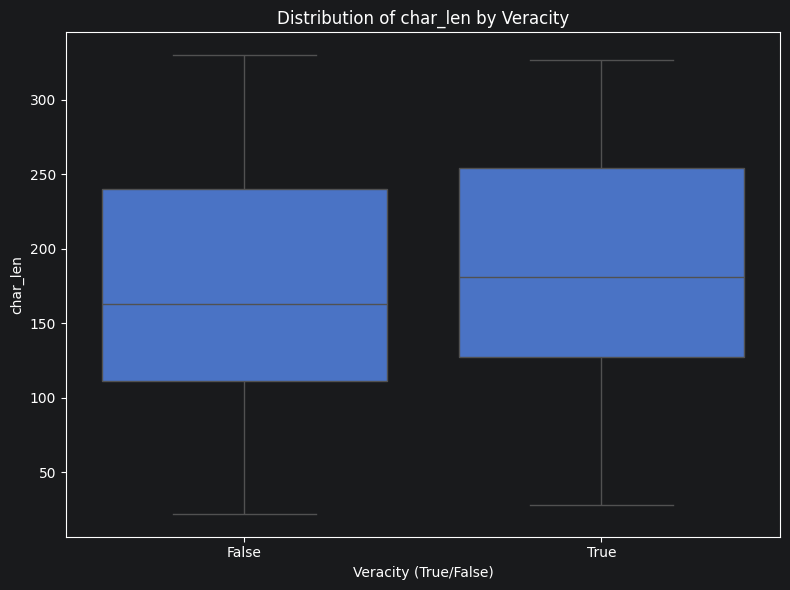

char_len: p=1.8067e-08 | Significant
Effect size: -0.11047235840450664
--------------------------------------------------


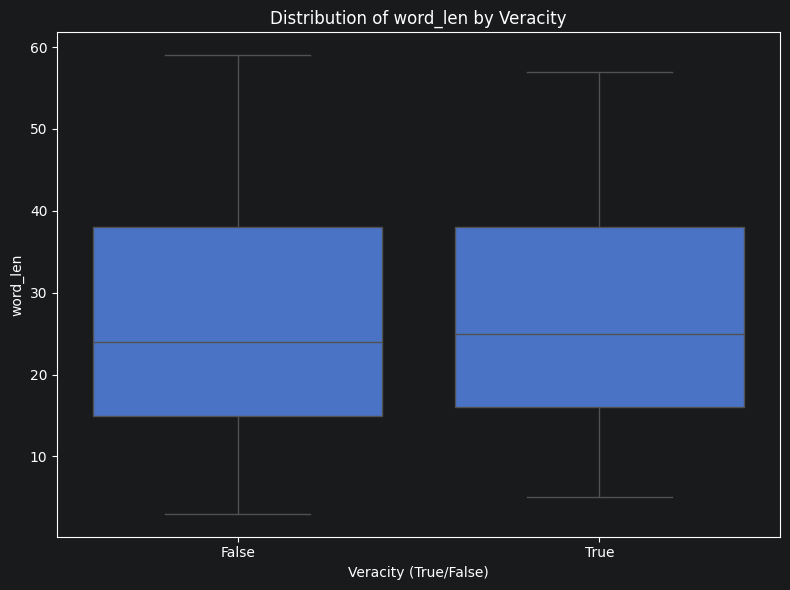

word_len: p=3.4957e-01 | Not significant
Effect size: -0.018350933300613992
--------------------------------------------------


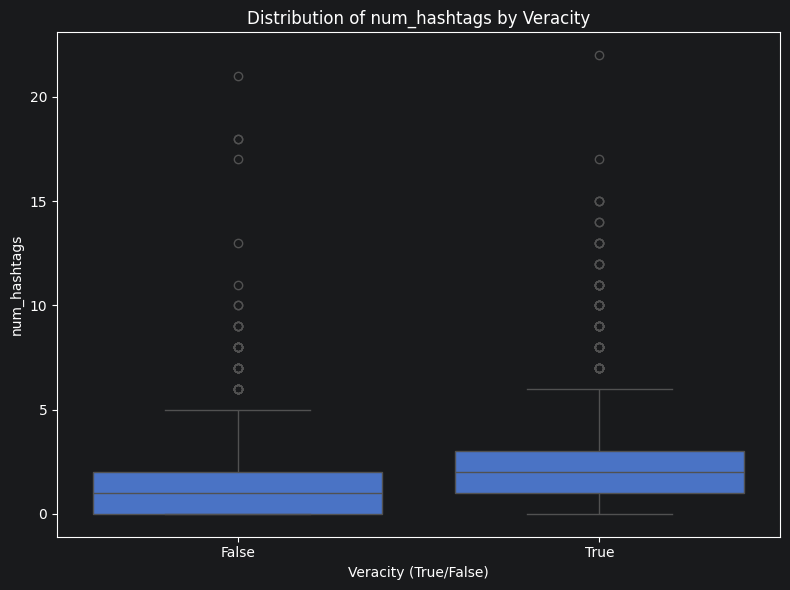

num_hashtags: p=5.1595e-28 | Significant
Effect size: -0.20962287880161967
--------------------------------------------------


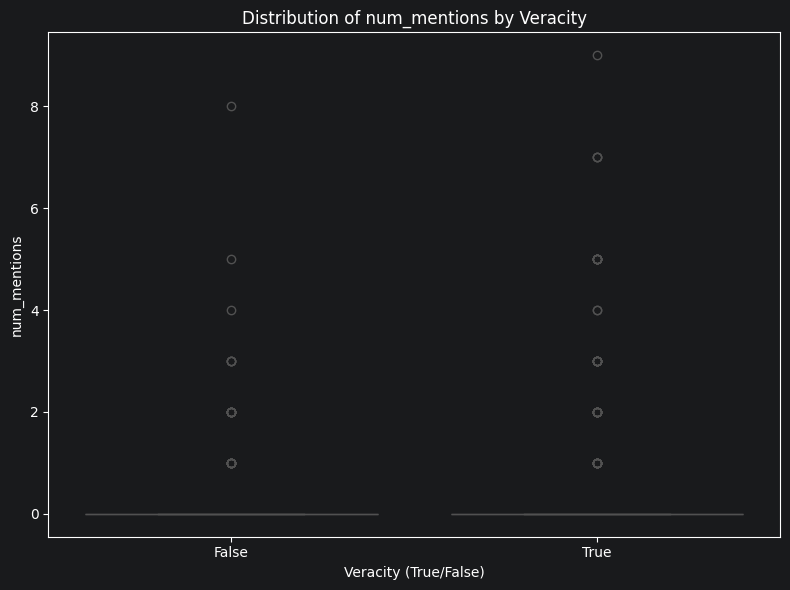

num_mentions: p=5.6040e-05 | Significant
Effect size: -0.04756192218849531
--------------------------------------------------


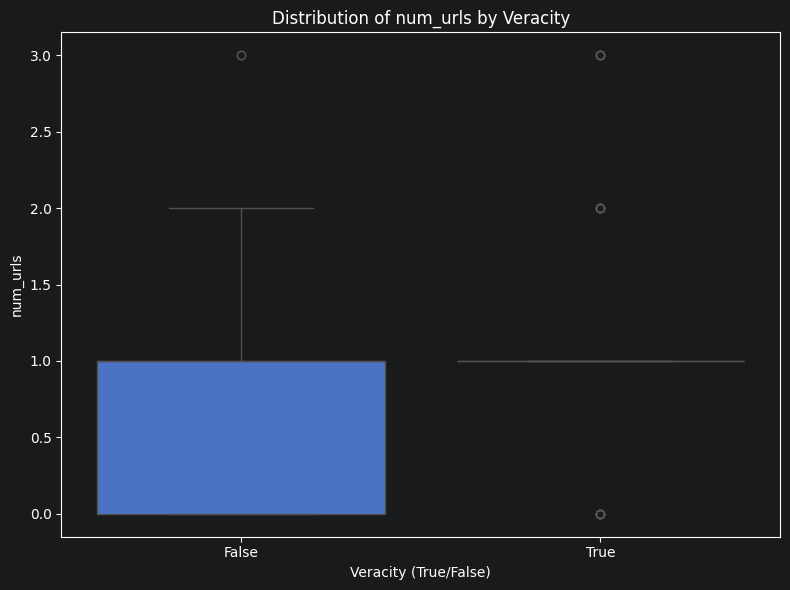

num_urls: p=3.7595e-26 | Significant
Effect size: -0.1797193829920034
--------------------------------------------------


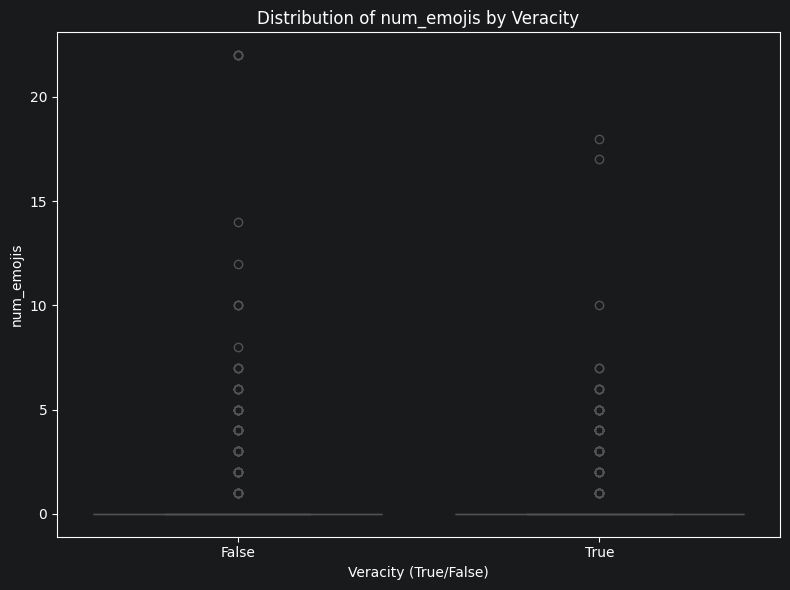

num_emojis: p=1.1712e-05 | Significant
Effect size: 0.06077656799304354
--------------------------------------------------


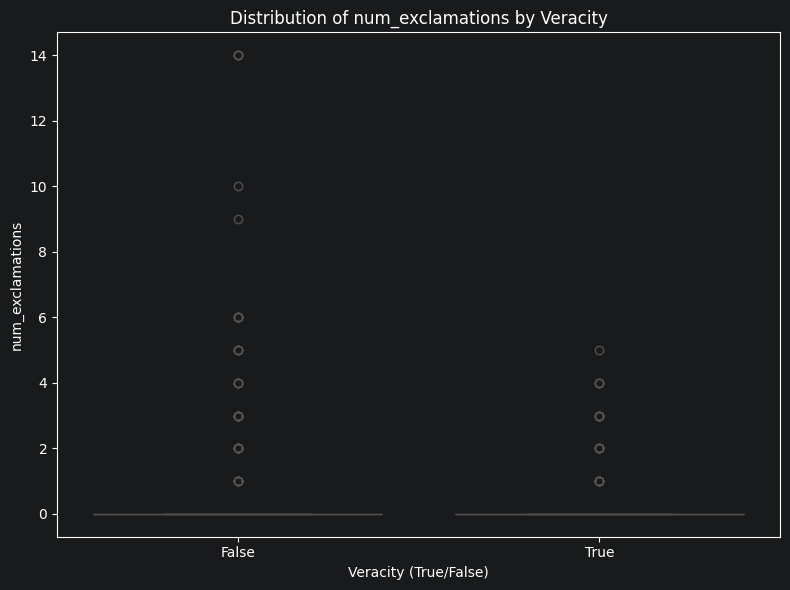

num_exclamations: p=2.5274e-04 | Significant
Effect size: 0.032568830586867104
--------------------------------------------------


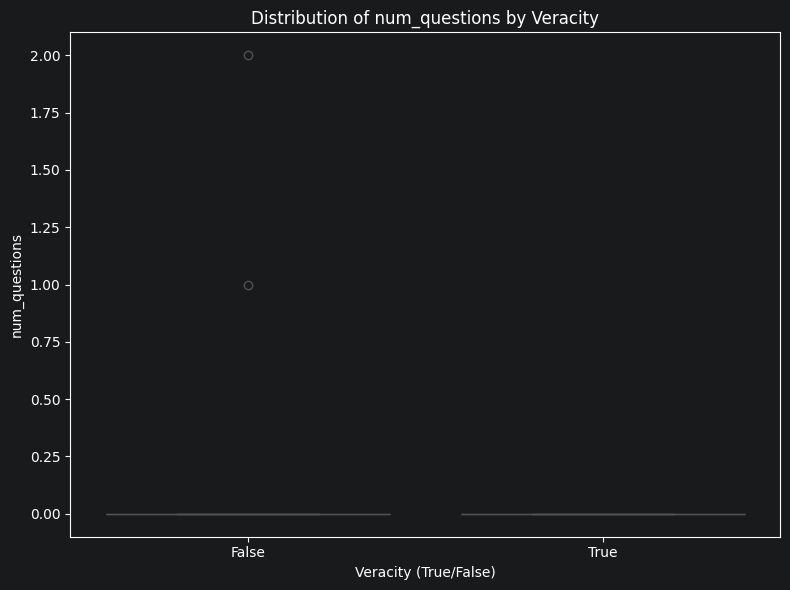

num_questions: p=1.5164e-01 | Not significant
Effect size: 0.0011709601873536313
--------------------------------------------------


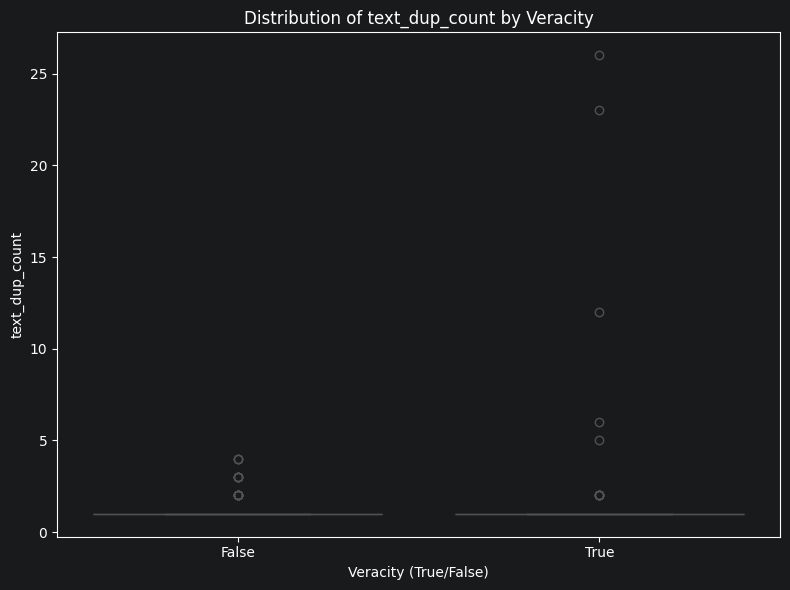

text_dup_count: p=2.2509e-03 | Significant
Effect size: 0.011886646252660671
--------------------------------------------------


In [14]:
# 1. Melt the feature columns (excluding tweetID, label, tweetText)
feature_cols = ['char_len', 'word_len', 'num_hashtags', 'num_mentions',
                'num_urls', 'num_emojis', 'num_exclamations', 'num_questions', 'text_dup_count']

for col in feature_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=tweets_df_dedup, x='label', y=col)
    plt.title(f'Distribution of {col} by Veracity')
    plt.xlabel('Veracity (True/False)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

    # Optional: print statistics for this feature
    true_vals = tweets_df_dedup[tweets_df_dedup['label'] == True][col]
    false_vals = tweets_df_dedup[tweets_df_dedup['label'] == False][col]
    stat, p = mannwhitneyu(true_vals, false_vals, alternative='two-sided')
    u, p = mannwhitneyu(true_vals, false_vals)
    n1, n2 = len(true_vals), len(false_vals)
    effect_size = 1 - (2 * u) / (n1 * n2)
    print(f"{col}: p={p:.4e} | {'Significant' if p<0.05 else 'Not significant'}")
    print(f"Effect size: {effect_size}")
    print("-" * 50)

In [15]:
feature_cols = ['char_len', 'word_len', 'num_hashtags', 'num_mentions',
                'num_urls', 'num_emojis', 'num_exclamations', 'text_dup_count']  # , 'num_questions'
X = tweets_df_dedup[feature_cols]
y = tweets_df_dedup['label']
model = RandomForestClassifier()
model.fit(X, y)
importances = pd.Series(model.feature_importances_, index=feature_cols)
print(importances.sort_values(ascending=False))

char_len            0.431106
word_len            0.266314
num_hashtags        0.120174
num_emojis          0.058703
num_urls            0.050077
num_mentions        0.034711
num_exclamations    0.033172
text_dup_count      0.005744
dtype: float64


In [16]:
tweets_df_dedup = tweets_df_dedup.drop('num_questions', axis=1) # dropped since it has no effect in both tests

In [17]:
# tweets_df_dedup = tweets_df_dedup.drop('text_dup_count', axis=1)

will decide later on if "text_dup_count" should be dropped based on other tests for duplicates effects

## 6. Adding propagation features (replies, retweets)


In [18]:
replies_file = '../../ArCOV19-Rumors/tweet_verification/propagation_networks/replies'
retweets_file = '../../ArCOV19-Rumors/tweet_verification/propagation_networks/retweets'

reply_counts = parse_propagation_file(replies_file)
retweet_counts = parse_propagation_file(retweets_file)

In [19]:
tweets_df_dedup['num_replies'] = tweets_df_dedup['tweetID'].apply(lambda tid: reply_counts.get(str(tid), 0))
tweets_df_dedup['num_retweets'] = tweets_df_dedup['tweetID'].apply(lambda tid: retweet_counts.get(str(tid), 0))


In [20]:
feature_cols = ['char_len', 'word_len', 'num_hashtags', 'num_mentions',
                'num_urls', 'num_emojis', 'num_exclamations', 'num_replies', 'num_retweets']  # , 'num_questions'
X = tweets_df_dedup[feature_cols]
y = tweets_df_dedup['label']
model = RandomForestClassifier()
model.fit(X, y)
importances = pd.Series(model.feature_importances_, index=feature_cols)
print(importances.sort_values(ascending=False))

char_len            0.316668
word_len            0.222806
num_hashtags        0.110941
num_replies         0.094671
num_retweets        0.091981
num_emojis          0.054777
num_urls            0.049230
num_exclamations    0.029833
num_mentions        0.029092
dtype: float64


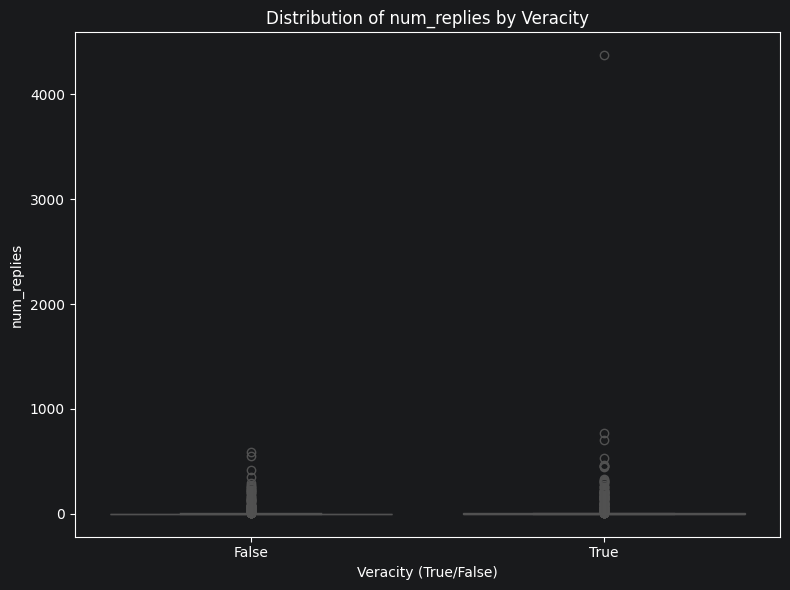

num_replies: p=1.8193e-02 | Significant
Effect size: -0.03925217254458446
--------------------------------------------------


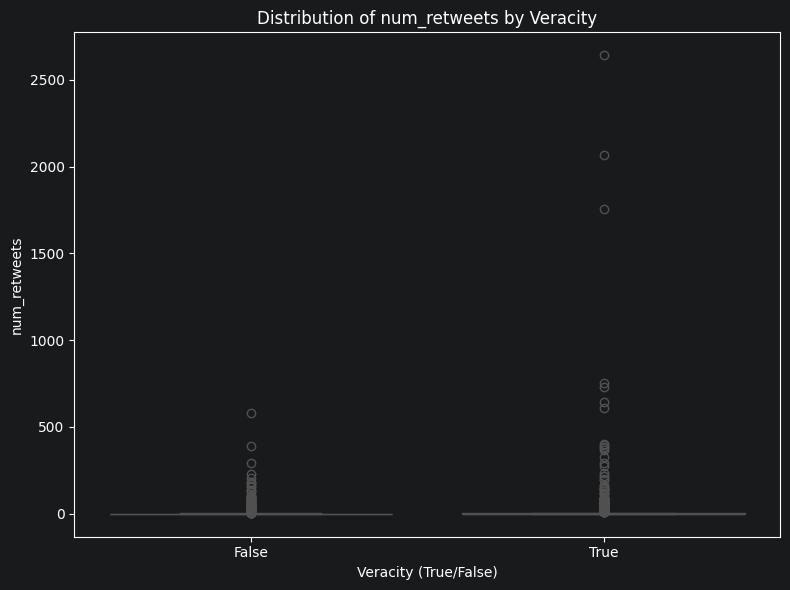

num_retweets: p=3.6534e-19 | Significant
Effect size: -0.1608723253295492
--------------------------------------------------


In [21]:
# 1. Melt the feature columns (excluding tweetID, label, tweetText)
feature_cols = ['num_replies', 'num_retweets']

for col in feature_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=tweets_df_dedup, x='label', y=col)
    plt.title(f'Distribution of {col} by Veracity')
    plt.xlabel('Veracity (True/False)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

    # Optional: print statistics for this feature
    true_vals = tweets_df_dedup[tweets_df_dedup['label'] == True][col]
    false_vals = tweets_df_dedup[tweets_df_dedup['label'] == False][col]
    stat, p = mannwhitneyu(true_vals, false_vals, alternative='two-sided')
    u, p = mannwhitneyu(true_vals, false_vals)
    n1, n2 = len(true_vals), len(false_vals)
    effect_size = 1 - (2 * u) / (n1 * n2)
    print(f"{col}: p={p:.4e} | {'Significant' if p<0.05 else 'Not significant'}")
    print(f"Effect size: {effect_size}")
    print("-" * 50)

## 7. Feature correlation heatmap


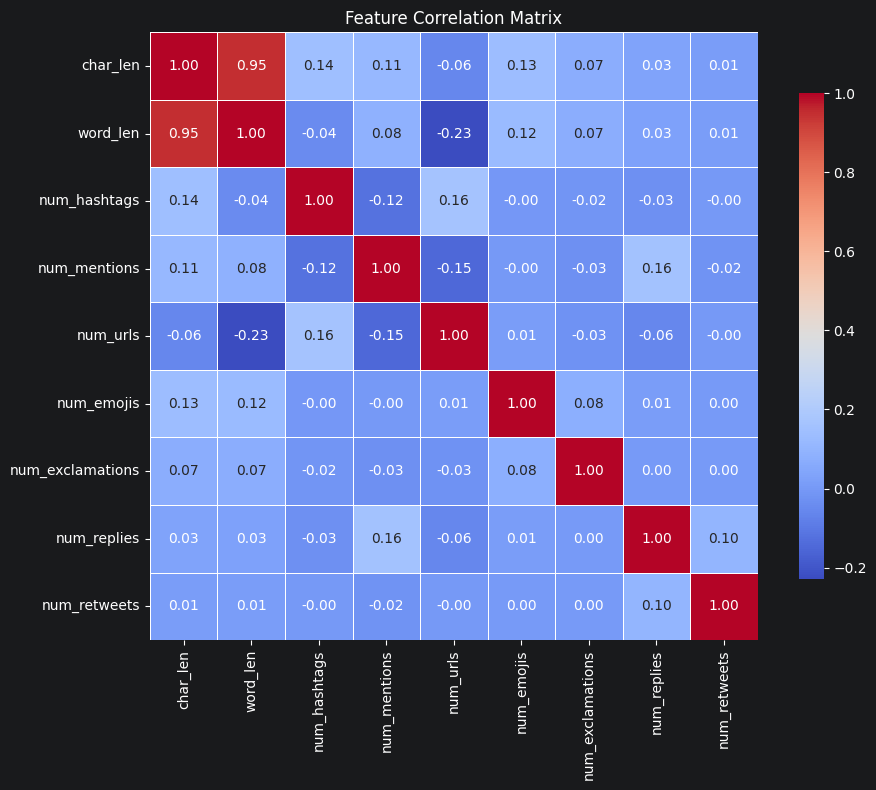

In [22]:
# Features we plan to use (including the new ones)
features = [
    'char_len', 'word_len', 'num_hashtags',
    'num_mentions', 'num_urls', 'num_emojis',
    'num_exclamations', 'num_replies', 'num_retweets'
]

# Ensure all features exist in the dataframe
missing = [f for f in features if f not in tweets_df_dedup.columns]
if missing:
    print(f"Missing columns: {missing}")
else:
    # Compute correlation matrix
    corr = tweets_df_dedup[features].corr()

    # Plot heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Feature Correlation Matrix')
    plt.tight_layout()
    plt.show()

"char_len" and "word_len" are highly correlated, might drop "word_len" since it has lower effect, also testing for a fusion of both and it's effect.

In [23]:
# Avoid division by zero (word_len might be 0 for empty tweets)
tweets_df_dedup['avg_word_length'] = tweets_df_dedup['char_len'] / tweets_df_dedup['word_len'].replace(0, np.nan)

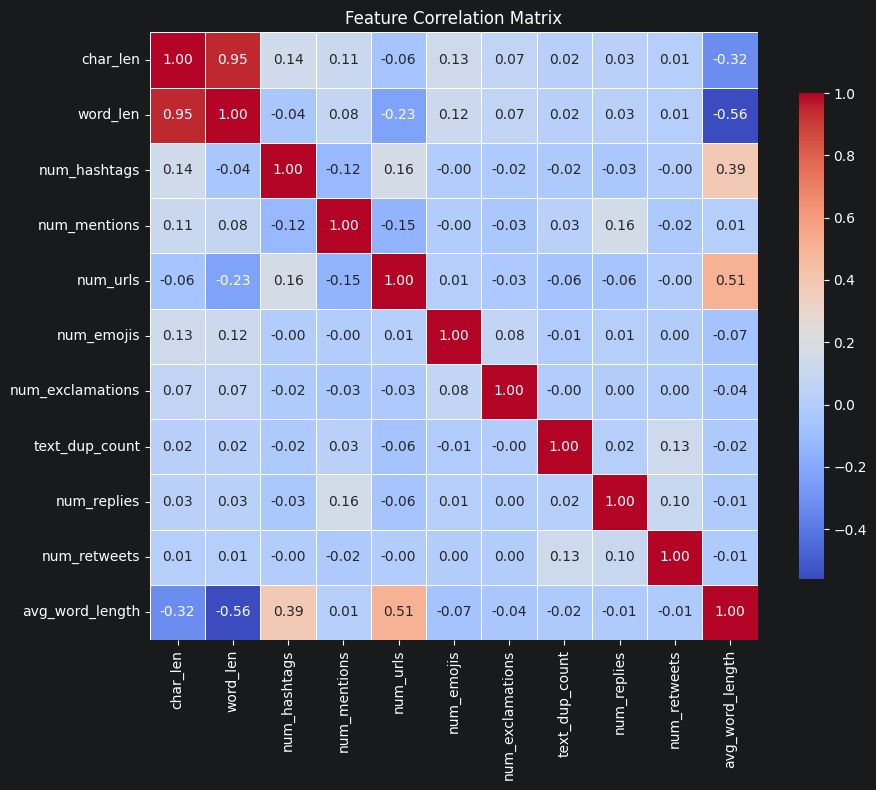

In [24]:
features = [
    'char_len', 'word_len', 'num_hashtags',
    'num_mentions', 'num_urls', 'num_emojis',
    'num_exclamations', 'text_dup_count', 'num_replies', 'num_retweets','avg_word_length'
]

# Ensure all features exist in the dataframe
missing = [f for f in features if f not in tweets_df_dedup.columns]
if missing:
    print(f"Missing columns: {missing}")
else:
    # Compute correlation matrix
    corr = tweets_df_dedup[features].corr()

    # Plot heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Feature Correlation Matrix')
    plt.tight_layout()
    plt.show()

In [25]:
X_vif = tweets_df_dedup[features].dropna()

vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data)

             feature         VIF
0           char_len  187.004195
1           word_len  136.105983
2       num_hashtags    3.013992
3       num_mentions    1.299133
4           num_urls    4.396603
5         num_emojis    1.143210
6   num_exclamations    1.055461
7     text_dup_count    3.756496
8        num_replies    1.057121
9       num_retweets    1.045490
10   avg_word_length   11.384375


This proves that "char_len" and "word_len" are co-linear which causes unstable coefficients in linear models so we have to drop one.

Given these correlation patterns and co-linearity test, and to avoid redundancy, I dropped the original word_len feature while keeping avg_word_length. This substitution retains the essential word‑length information while improving feature independence and model interpretability.

In [26]:
tweets_df_dedup = tweets_df_dedup.drop('word_len', axis=1)

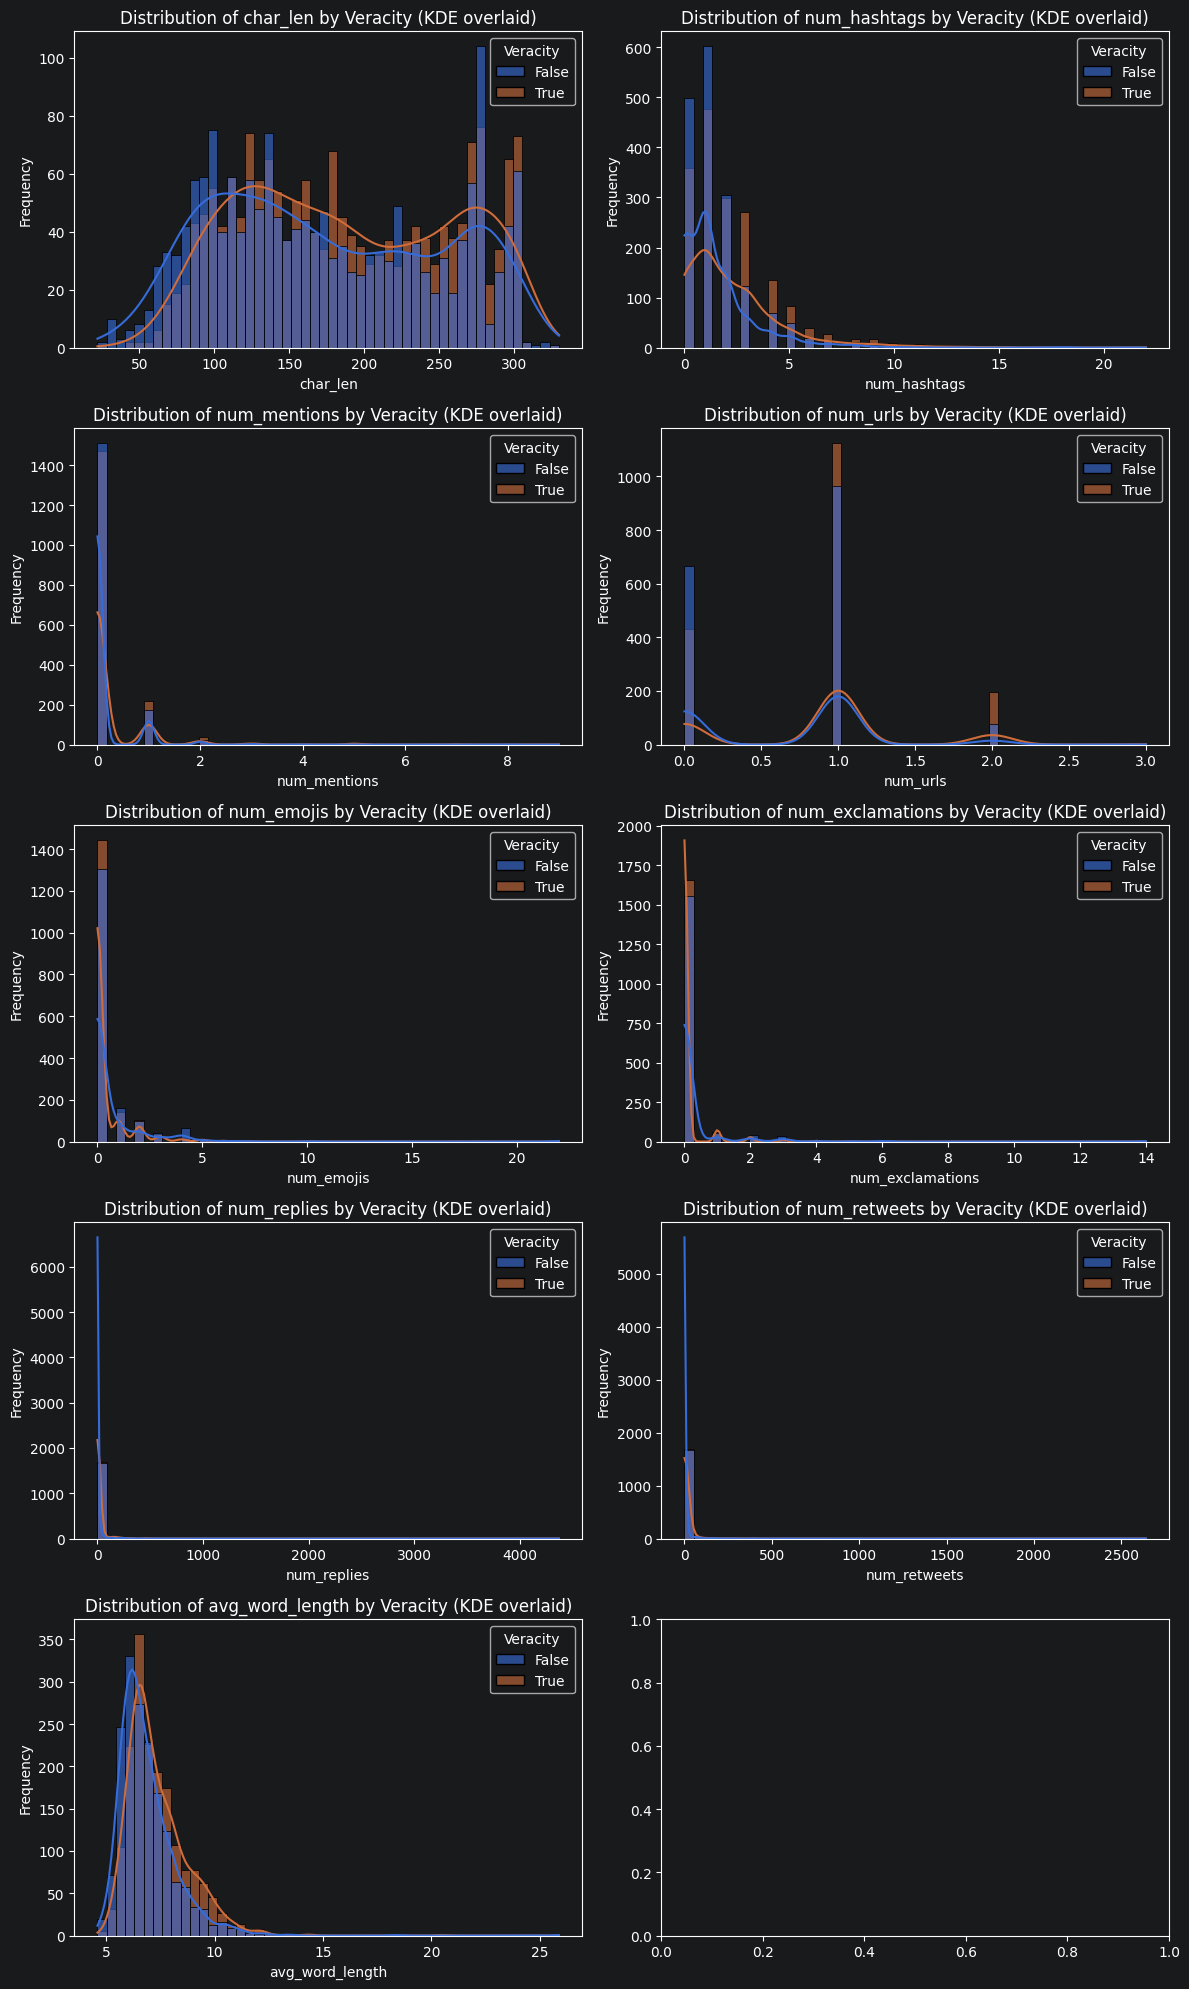

In [27]:
dist_features = ['char_len', 'num_hashtags', 'num_mentions',
                'num_urls', 'num_emojis', 'num_exclamations', 'num_replies', 'num_retweets','avg_word_length']

fig, axes = plt.subplots(5, 2, figsize=(12, 20))
axes = axes.flatten()

for ax, col in zip(axes, dist_features):
    sns.histplot(data=tweets_df_dedup, x=col, hue='label', kde=True, bins=50, alpha=0.6, ax=ax)
    ax.set_title(f'Distribution of {col} by Veracity (KDE overlaid)')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    legend = ax.get_legend()
    if legend:
        legend.set_title('Veracity')

for ax in axes[len(features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

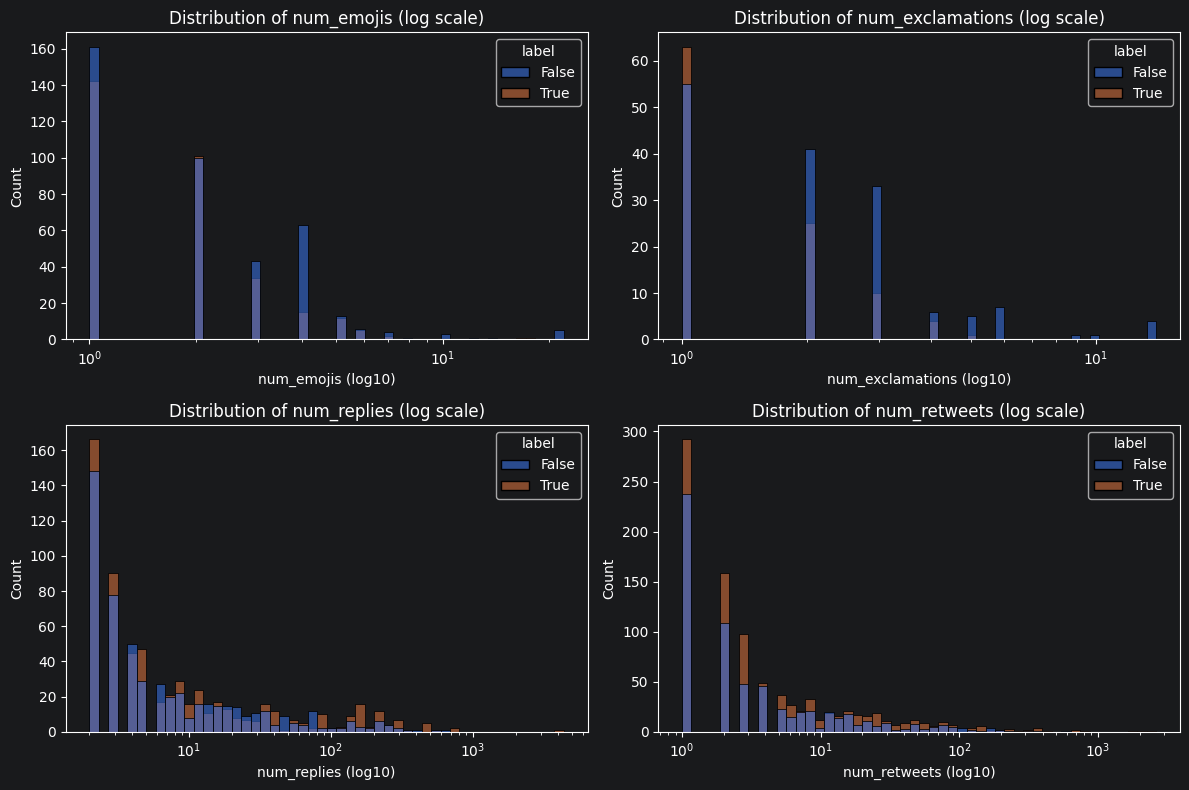

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flat, ['num_emojis', 'num_exclamations','num_replies', 'num_retweets']):
    sns.histplot(data=tweets_df_dedup, x=col, hue='label', bins=50,
                 log_scale=True, alpha=0.6, ax=ax)
    ax.set_title(f'Distribution of {col} (log scale)')
    ax.set_xlabel(f'{col} (log10)')
plt.tight_layout()
plt.show()

## 8. Random Forest feature importance (various feature sets)


In [29]:
feature_cols = ['char_len', 'num_hashtags', 'num_mentions',
                'num_urls', 'num_emojis', 'num_exclamations', 'num_replies', 'num_retweets','avg_word_length']
X = tweets_df_dedup[feature_cols]
y = tweets_df_dedup['label']
model = RandomForestClassifier()
model.fit(X, y)
importances = pd.Series(model.feature_importances_, index=feature_cols)
print(importances.sort_values(ascending=False))

avg_word_length     0.295224
char_len            0.280201
num_hashtags        0.103659
num_retweets        0.087200
num_replies         0.082759
num_emojis          0.049777
num_urls            0.045239
num_exclamations    0.028927
num_mentions        0.027014
dtype: float64


In [30]:
# included "text_dup_count" for comparision
feature_cols = ['char_len', 'num_hashtags', 'num_mentions',
                'num_urls', 'num_emojis', 'num_exclamations', 'text_dup_count', 'num_replies', 'num_retweets','avg_word_length']
X = tweets_df_dedup[feature_cols]
y = tweets_df_dedup['label']
model = RandomForestClassifier()
model.fit(X, y)
importances = pd.Series(model.feature_importances_, index=feature_cols)
print(importances.sort_values(ascending=False))

avg_word_length     0.294553
char_len            0.277254
num_hashtags        0.103661
num_retweets        0.085398
num_replies         0.084762
num_emojis          0.050985
num_urls            0.042798
num_exclamations    0.028627
num_mentions        0.027733
text_dup_count      0.004228
dtype: float64


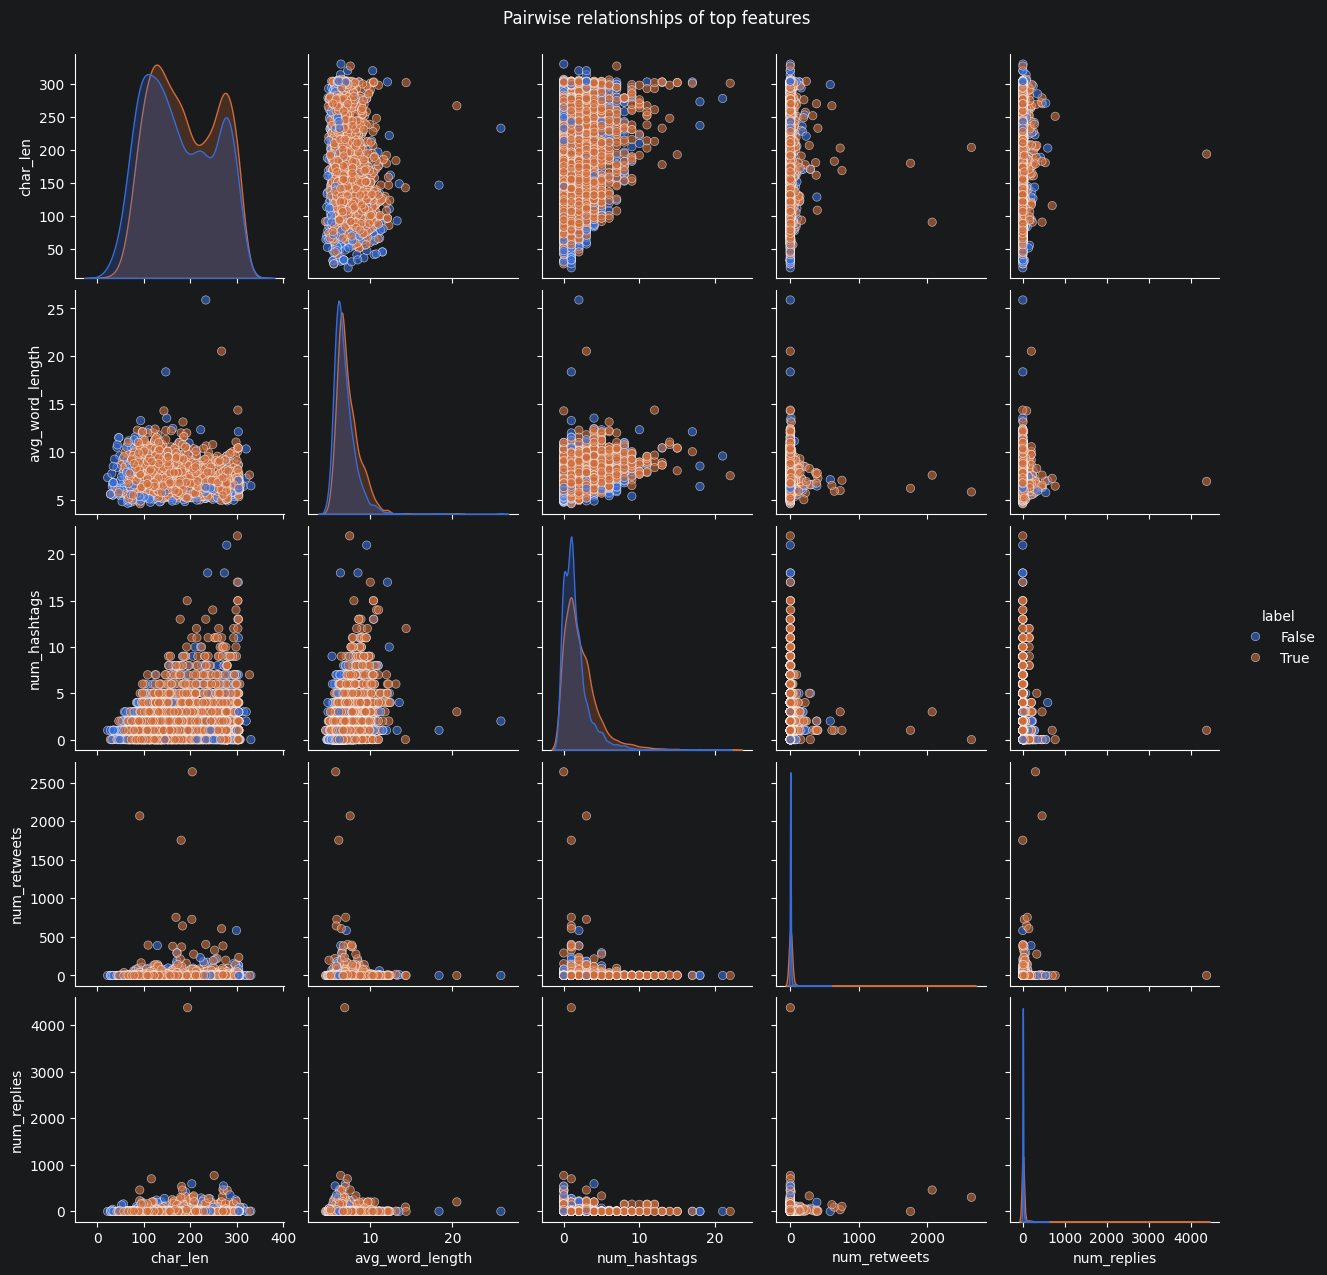

In [31]:
top_features = ['char_len', 'avg_word_length', 'num_hashtags', 'num_retweets', 'num_replies']

# Pairplot with hue = label
sns.pairplot(tweets_df_dedup[top_features + ['label']], hue='label', diag_kind='kde', plot_kws={'alpha':0.6})
plt.suptitle('Pairwise relationships of top features', y=1.02)
plt.show()

## 9. Comparing deduplication strategies


In [32]:
# Assuming tweets_df is already loaded and has basic features
# Add propagation features
tweets_df['num_replies'] = tweets_df['tweetID'].apply(lambda tid: reply_counts.get(str(tid), 0))
tweets_df['num_retweets'] = tweets_df['tweetID'].apply(lambda tid: retweet_counts.get(str(tid), 0))

# Add avg_word_length (avoid division by zero)
tweets_df['avg_word_length'] = tweets_df['char_len'] / tweets_df['word_len'].replace(0, np.nan)


In [33]:
feature_cols = [
    'char_len', 'num_hashtags', 'num_mentions',
    'num_urls', 'num_emojis', 'num_exclamations',
    'text_dup_count', 'num_replies', 'num_retweets', 'avg_word_length'
]

In [34]:
# Prepare full dataset
X_full = tweets_df[feature_cols].copy()
y_full = tweets_df['label']

# Prepare deduplicated dataset (assuming it already has the same features)
X_dedup = tweets_df_dedup[feature_cols].copy()
y_dedup = tweets_df_dedup['label']

# Define model and CV
model = RandomForestClassifier(random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate
scores_full = cross_val_score(model, X_full, y_full, cv=cv, scoring='accuracy')
scores_dedup = cross_val_score(model, X_dedup, y_dedup, cv=cv, scoring='accuracy')

print(f"Full dataset CV accuracy: {scores_full.mean():.4f} ± {scores_full.std():.4f}")
print(f"Dedup dataset CV accuracy: {scores_dedup.mean():.4f} ± {scores_dedup.std():.4f}")

Full dataset CV accuracy: 0.6735 ± 0.0164
Dedup dataset CV accuracy: 0.6712 ± 0.0079


In [35]:
# Train on full data
model_full = RandomForestClassifier(random_state=42)
model_full.fit(X_full, y_full)

# Train on dedup data
model_dedup = RandomForestClassifier(random_state=42)
model_dedup.fit(X_dedup, y_dedup)

# Compare importances for num_replies and num_retweets
importances_full = pd.Series(model_full.feature_importances_, index=feature_cols)
importances_dedup = pd.Series(model_dedup.feature_importances_, index=feature_cols)

print("Full dataset feature importances:\n", importances_full.sort_values(ascending=False))
print("\nDedup dataset feature importances:\n", importances_dedup.sort_values(ascending=False))

Full dataset feature importances:
 avg_word_length     0.292665
char_len            0.271162
num_hashtags        0.099706
num_retweets        0.085601
num_replies         0.080318
num_emojis          0.049493
num_urls            0.042764
num_mentions        0.028584
num_exclamations    0.027856
text_dup_count      0.021850
dtype: float64

Dedup dataset feature importances:
 avg_word_length     0.294179
char_len            0.274914
num_hashtags        0.106488
num_retweets        0.086543
num_replies         0.084394
num_emojis          0.049309
num_urls            0.044217
num_exclamations    0.028552
num_mentions        0.027503
text_dup_count      0.003902
dtype: float64


In [36]:
# Original (no sorting before dedup)
df_orig = tweets_df.drop_duplicates(subset='tweetText', keep='first').copy()

# Sort by tweetID ascending (oldest first)
df_earliest = tweets_df.sort_values('tweetID', ascending=True).drop_duplicates(subset='tweetText', keep='first').copy()

# Sort by retweets and replies descending (most propagated first)
df_most_propagated = tweets_df.sort_values(['num_retweets', 'num_replies'], ascending=False).drop_duplicates(subset='tweetText', keep='first').copy()

In [37]:
feature_cols = [
    'char_len', 'num_hashtags', 'num_mentions',
    'num_urls', 'num_emojis', 'num_exclamations',
    'num_replies', 'num_retweets', 'avg_word_length'
]

In [38]:
model = RandomForestClassifier(random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, df in [('Original (unsorted)', df_orig),
                 ('Earliest (tweetID asc)', df_earliest),
                 ('Most propagated (retweets+replies desc)', df_most_propagated)]:
    X = df[feature_cols]
    y = df['label']
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    results[name] = {'mean': scores.mean(), 'std': scores.std()}
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}")

Original (unsorted): 0.6645 ± 0.0088
Earliest (tweetID asc): 0.6634 ± 0.0123
Most propagated (retweets+replies desc): 0.6674 ± 0.0129


In [39]:
print("Rows kept after dedup:")
print(f"Original: {len(df_orig)}")
print(f"Earliest: {len(df_earliest)}")
print(f"Most propagated: {len(df_most_propagated)}")

Rows kept after dedup:
Original: 3464
Earliest: 3464
Most propagated: 3464


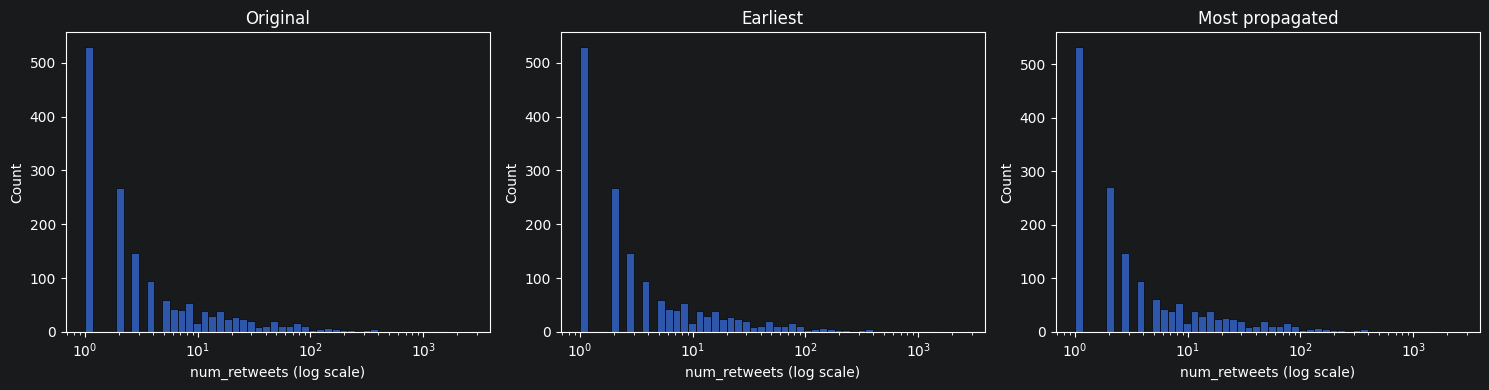

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, df) in zip(axes, [('Original', df_orig), ('Earliest', df_earliest), ('Most propagated', df_most_propagated)]):
    sns.histplot(df['num_retweets'], bins=50, log_scale=True, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('num_retweets (log scale)')
plt.tight_layout()
plt.show()

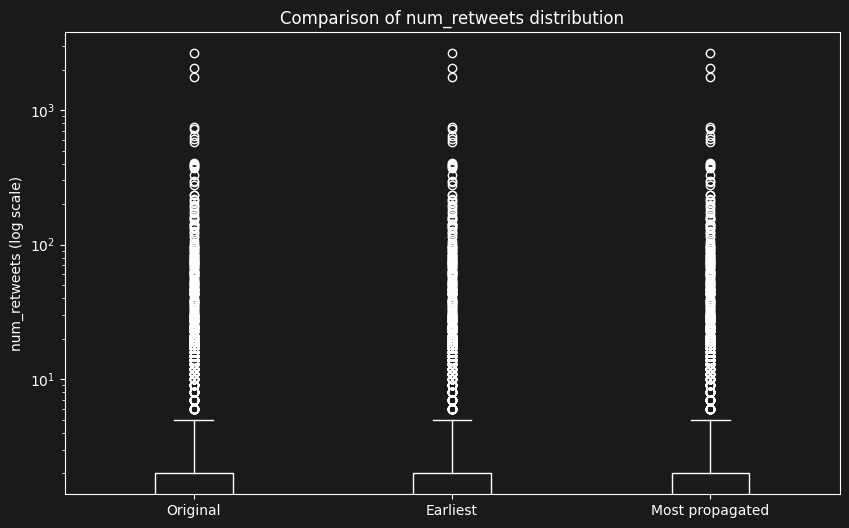

In [41]:
plt.figure(figsize=(10, 6))
data_to_plot = [df_orig['num_retweets'], df_earliest['num_retweets'], df_most_propagated['num_retweets']]
plt.boxplot(data_to_plot, tick_labels=['Original', 'Earliest', 'Most propagated'])
plt.yscale('log')
plt.ylabel('num_retweets (log scale)')
plt.title('Comparison of num_retweets distribution')
plt.show()

Duplicates (and their counts) don’t help the model much – probably because there are too few of them in the data. Keeping them risks data leakage. So I’m deduplicating (keep first occurrence) and dropping text_dup_count from the feature set.

In [42]:
tweets_df_dedup = tweets_df_dedup.drop('text_dup_count', axis=1)

## 10. Final evaluation on cleaned feature set

5-fold CV accuracy: 0.6645 ± 0.0088
Train/test split accuracy: 0.6652
Test set AUC: 0.717
Test set Average Precision: 0.708
Best F1 threshold: 0.4400
Precision at that threshold: 0.6625, Recall: 0.7607


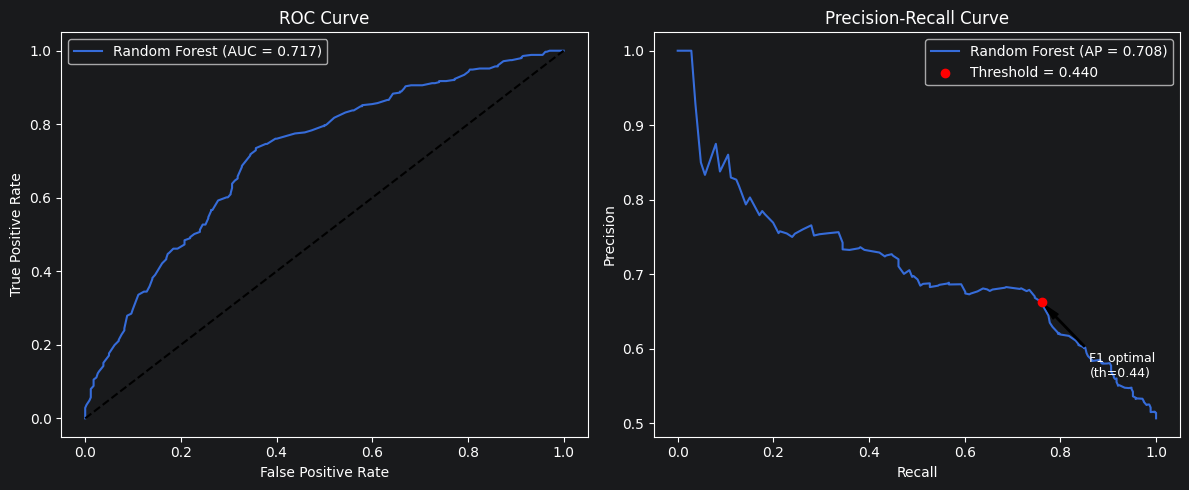


Final feature importances:
 avg_word_length     0.291444
char_len            0.275435
num_hashtags        0.110512
num_retweets        0.092305
num_replies         0.080743
num_emojis          0.051751
num_urls            0.044492
num_mentions        0.027130
num_exclamations    0.026187
dtype: float64


In [43]:
# Define final feature set (after dropping word_len and text_dup_count)
final_features = [
    'char_len', 'num_hashtags', 'num_mentions',
    'num_urls', 'num_emojis', 'num_exclamations',
    'num_replies', 'num_retweets', 'avg_word_length'
]

# Prepare data
X_final = tweets_df_dedup[final_features].copy()
y_final = tweets_df_dedup['label']

# Cross-validation

model = RandomForestClassifier(random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(model, X_final, y_final, cv=cv, scoring='accuracy')
print(f"5-fold CV accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Train/test split (80/20) for final estimate
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

model.fit(X_train, y_train)
test_acc = model.score(X_test, y_test)
print(f"Train/test split accuracy: {test_acc:.4f}")

y_proba = model.predict_proba(X_test)[:, 1]

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

# Precision-Recall curve
precision, recall, thresholds_pr  = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

print(f"Test set AUC: {roc_auc:.3f}")
print(f"Test set Average Precision: {ap:.3f}")



# Compute F1 score for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)  # avoid division by zero

# Find threshold that maximizes F1
best_idx = np.argmax(f1_scores)
best_threshold = thresholds_pr[best_idx]
best_precision = precision[best_idx]
best_recall = recall[best_idx]

print(f"Best F1 threshold: {best_threshold:.4f}")
print(f"Precision at that threshold: {best_precision:.4f}, Recall: {best_recall:.4f}")

# Annotate on the PR curve plot
plt.subplot(1, 2, 2)
plt.plot(recall, precision, label=f'Random Forest (AP = {ap:.3f})')
plt.scatter(best_recall, best_precision, color='red', zorder=5, label=f'Threshold = {best_threshold:.3f}')
plt.annotate(f'F1 optimal\n(th={best_threshold:.2f})',
             xy=(best_recall, best_precision),
             xytext=(best_recall + 0.1, best_precision - 0.1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             fontsize=9)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

plt.tight_layout()
plt.show()

# Feature importance on final model
importances_final = pd.Series(model.feature_importances_, index=final_features)
print("\nFinal feature importances:\n", importances_final.sort_values(ascending=False))


## 11. Conclusions

- Length matters most – char_len and avg_word_length are the strongest predictors by far. I dropped word_len since it was redundant with char_len.

- Hashtags help – num_hashtags is highly significant and consistently ranks high in feature importance.

- Propagation signals add value – num_retweets and num_replies both show significant differences and contribute meaningfully, though less than length/hashtags.

- Other surface features – emojis, URLs, and mentions are statistically significant but have low impact. Exclamations and questions are weak; I dropped num_questions entirely.

- Duplicates don't help – keeping them created potential leakage, and text_dup_count had negligible importance. I deduplicated (keep first) and dropped that feature.

- Baseline performance – With the final 9 features, a Random Forest hits ~0.67 CV accuracy. Not earth-shattering, but solid for hand-crafted features on Arabic COVID-19 rumors.

- Next steps – Could go deeper with embeddings or transformers, but this feature set gives a good, interpretable starting point.